In [59]:
import datetime
import pandas as pd
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from scipy.interpolate import RegularGridInterpolator
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [60]:
## 从NC文件时间转PD时间
def cftime2pdtime(cf):
    return pd.to_datetime(datetime.datetime(cf.year,cf.month,cf.day,cf.hour))

## 获取文件夹里所有NC文件
def getfiles(filed):
    files=listdir(filed)
    files.sort()
    files = files[:]
    return [f'{filed}/{i}' for i in files]

In [61]:
dataAdd=getfiles('data/BRAN/temp_zip')
temp=np.load('bran_temp.npy')
times=pd.date_range('1993-01-01','2022-12-31',freq='1D')

In [62]:
np.load(dataAdd[0]).shape

(1, 34, 451, 1001)

In [63]:
das1=nc.Dataset('/lustre/home/yuhanxue/data/BRAN/ERA5_4Q/1993_150E_180.nc')
das2=nc.Dataset('/lustre/home/yuhanxue/data/BRAN/ERA5_4Q/1993_0_70W.nc')
lon1=np.array(das1['longitude'])
lon2=np.array(das2['longitude'])
lat_e=np.array(das1['latitude'])[::-1]
lon_e=np.concatenate([lon1[:-1],lon2+360])
lon_e=np.arange(np.min(lon_e),np.max(lon_e)+1,2)
lat_e=np.arange(np.min(lat_e), np.max(lat_e)+1, 2)
s=np.load('/lustre/home/yuhanxue/data/BRAN/BRAN_lon_lat_level.npz')
lon_B=s['lon']
lat_B=s['lat']
lon_4=lon_e
lat_4=lat_e
lon_12=lon_B
lat_12=lat_B
Lon_4,Lat_4=np.meshgrid(lon_4,lat_4)
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
print(f'lat_12 range:{lat_12[0]:.2f}~{lat_12[-1]:.2f} | freq:{abs(lat_12[1]-lat_12[0])}\nlon_12 range:{lon_12[0]:.2f}~{lon_12[-1]:.2f} | freq:{lon_12[1]-lon_12[0]}')
def grid(dat):
    global lon_12,lat_12,Lon_4,Lat_4
    #print(dat.shape)
    #f=RegularGridInterpolator((lat_12,lon_12),godas_mlds[1,:,:],bounds_error=False,method='qubic',fill_value=np.nan)
    return RegularGridInterpolator((lat_12,lon_12),dat,bounds_error=False,fill_value=np.nan)((Lat_4,Lon_4))
def list_map(dat):
    pool = ThreadPoolExecutor(max_workers=4)
    ans=np.array(list(pool.map(grid,dat)))
    del pool
    return ans
def allinone(dat):
    pool = ProcessPoolExecutor(max_workers=36)
    ans=np.array(list(pool.map(list_map,dat)))
    ans[ans<-1000]=np.nan
    del pool
    return ans
def changedata(st):
    global times
    global temp
    ind=times==pd.to_datetime(st.split('.')[0].split('temp_')[-1].replace('_','-'))
    temp[ind,:,:,:]=allinone(np.load(st))[:,:33,:,:]
[changedata(i) for i in dataAdd]

lat_4 range:20.00~60.00 | freq:2.0
lon_4 range:150.00~250.00 | freq:2.0
lat_12 range:19.95~64.95 | freq:0.09999847412109375
lon_12 range:149.95~249.95 | freq:0.100006103515625


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [71]:
temp[temp<-1000]=np.nan
temp[temp>200]=np.nan

/tmp/ipykernel_320933/1383922949.py:1: RuntimeWarning: Mean of empty slice
  test=np.nanmean(np.nanmean(np.nanmean(temp,axis=-1),axis=-1),axis=-1)


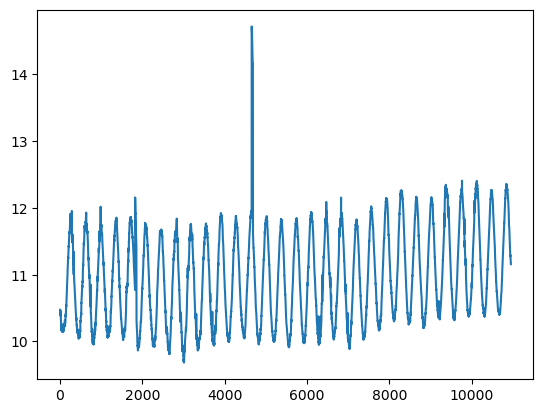

In [65]:
test=np.nanmean(np.nanmean(np.nanmean(temp,axis=-1),axis=-1),axis=-1)
#ind=test>=70
plt.plot(test)
# plt.ylim(0,40)
# plt.xlim(0,1000)

In [66]:
ind=test>=13

In [67]:
ind=test==np.max(test)
times[ind]

DatetimeIndex(['2005-10-02'], dtype='datetime64[ns]', freq='D')

In [72]:
np.nanmean(temp[ind,:,:,:])

15.850227898182974

/tmp/ipykernel_320933/1819113291.py:1: RuntimeWarning: Mean of empty slice
  plt.contourf(np.nanmean(temp[ind,:,:,:],axis=(0,1)))


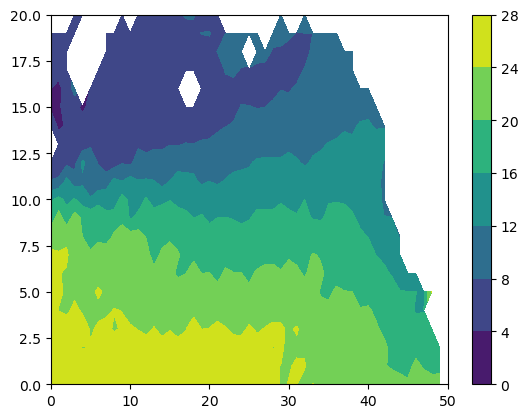

In [68]:
plt.contourf(np.nanmean(temp[ind,:,:,:],axis=(0,1)))
plt.colorbar()

In [69]:
temp[ind,0,:,:].shape

(1, 21, 51)

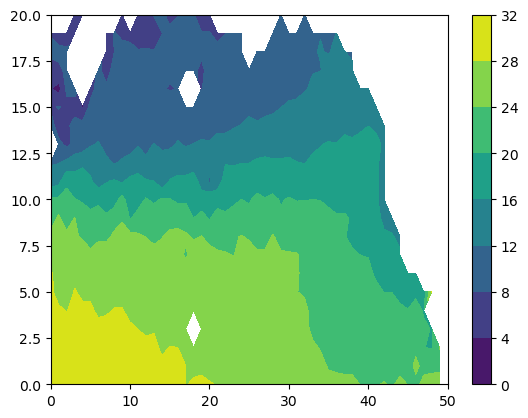

In [70]:
plt.contourf(temp[ind,4,:,:][0,:,:])
plt.colorbar()

In [ ]:
np.save('bran_temp.npy',temp)